In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
#  Step 1 — Create Large Datase

In [3]:
real_news = ["Government announces new budget plan for education sector",
    "Scientists find new treatment for diabetes in clinical trial",
    "Stock market rises after positive jobs report",
    "NASA launches new satellite to study climate change",
    "Prime Minister holds press conference on economic policy",
    "New study shows benefits of Mediterranean diet for heart health",
    "Electric vehicle sales hit record high this quarter",
    "Supreme court passes new ruling on environmental law",
    "UN holds summit on global food security crisis",
    "Hospital reports decline in covid cases this month",
    "Central bank keeps interest rates unchanged this quarter",
    "Scientists publish research on effects of climate change",
    "New law passed to protect consumer data privacy",
    "World health organization updates vaccine guidelines",
    "Tech company announces layoffs amid market slowdown",
    "India GDP growth rate projected at 6.5 percent in 2025 by IMF",
    "Supreme Court of India issues notice on electoral bonds case",
    "RBI keeps repo rate unchanged at 6.5 percent amid inflation concerns",
    "India successfully launches ISRO satellite for weather forecasting",
    "PM Modi inaugurates new expressway connecting Delhi to Mumbai",
    "India wins gold medal at Asian Games in athletics",
    "New education policy NEP 2020 implementation reviewed by ministry",
    "India signs trade agreement with UAE to boost exports",
    "Monsoon arrives early in Kerala says India meteorological department",
    "Government launches scheme to provide free health insurance to poor",
    "Indian Air Force conducts joint exercise with French air force",
    "Mumbai local train network gets upgrade with new coaches",
    "India overtakes China as most populous country says UN report",
    "Digital payments in India cross 10 billion transactions per month",
    "Election Commission announces dates for state assembly elections",
    "India bans single use plastics to reduce environmental pollution",
    "Chandrayaan-3 successfully lands on south pole of moon",
    "India joins G20 summit and chairs global climate discussion",
    "SEBI introduces new rules to protect retail investors in market",
    "Centre approves Rs 10000 crore for rural road development scheme",
    "India achieves record wheat production of 113 million tonnes",
    "New metro line inaugurated in Bengaluru to ease traffic",
    "Health ministry launches free tuberculosis treatment programme",
    "India wins bid to host 2036 Olympic Games in Ahmedabad",
    "Government raises minimum support price for paddy and wheat",
    "IIT Bombay ranks among top 150 universities globally in QS ranking",
    "India launches UPI payment system in several new countries",
    "Cabinet approves national hydrogen mission to boost clean energy",
    "Delhi air quality improves after odd even vehicle policy",
    "India and US sign defence cooperation agreement during state visit",
      "Researchers develop new malaria vaccine with 80 percent efficacy",
    "Parliament passes bill to regulate artificial intelligence use",
    "Central government increases pension for retired employees",
    "Scientists discover new species of bird in Amazon rainforest",
    "Global inflation eases as oil prices fall to two year low",
]

fake_news = [ "SHOCKING secret the government is hiding from everyone",
    "You won't believe what they found in the vaccine",
    "Miracle cure doctors don't want you to know about",
    "BREAKING celebrity caught in massive secret society scandal",
    "Deep state exposed share before they delete this",
    "Moon landing was faked whistleblower finally confirms",
    "Bill gates putting microchips in vaccines to control people",
    "Election was rigged insider reveals the truth now",
    "5G towers spreading virus wake up people",
    "Scientists STUNNED flat earth proof found in antarctica",
    "Secret cure for cancer hidden by big pharma exposed",
    "Chemtrails contain mind control chemicals truth revealed",
    "Hollywood elite running secret underground operations exposed",
    "EXCLUSIVE whistleblower leaks massive government cover up",
    "New world order plans leaked by anonymous insider",

    # India-specific fake news
    "SHOCKING Modi government secretly selling India to World Bank",
    "URGENT RBI to ban all cash transactions by next month share now",
    "You won't believe what they found inside Chandrayaan moon mission",
    "BREAKING India to become colony of China secret deal exposed",
    "Miracle Ayurvedic cure for cancer that AIIMS is hiding from you",
    "Government putting tracking chips in Aadhaar cards wake up",
    "EXPOSED Indian Army officers working for Pakistan secret proof",
    "Share before deleted PM Modi resigns secret audio leaked now",
    "Illuminati controls Indian elections insider finally reveals all",
    "5G towers in India causing mass bird deaths truth suppressed",
    "SHOCKING truth about tap water in India fluoride mind control",
    "Aliens landed in Rajasthan government covering it up share now",
    "Indian rupee to become worthless by end of year insiders say",
    "Secret underground tunnels found under Parliament building exposed",
    "WhatsApp forward URGENT new tax on all UPI payments above Rs 100",
    "BREAKING Rahul Gandhi arrested for treason share before deleted",
    "They are adding poison to packaged food sold in supermarkets",
    "NASA confirms India will experience total darkness for 7 days",
    "SHOCKING Bollywood stars involved in human trafficking ring exposed",
    "Secret society of judges controlling Supreme Court verdicts leaked",
    "Government hiding alien contact at ISRO facility whistleblower says",
    "URGENT forward this free Jio recharge offer expires in 1 hour",
    "Bill Gates funding poison in Indian vaccines to reduce population",
    "Election EVMs hacked by foreign country proof finally emerges",
    "Deep state planning to split India into 4 countries share now",
    "BREAKING cure for diabetes hidden by pharma companies in India",
    "Scientists discover India will sink into ocean in 10 years truth",
    "WhatsApp gold version has virus that steals your bank details",
    "Government secretly planning to ban gold ownership share now",
    "EXPOSED top IAS officers running organ harvesting racket in India",
]


In [ ]:
#  Step 2 — Build DataFrame

In [4]:
texts  = real_news + fake_news
labels = [0] * len(real_news) + [1] * len(fake_news)

df = pd.DataFrame({'text': texts, 'label': labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset created!')
print('Total rows    :', len(df))
print('Real news (0) :', (df['label'] == 0).sum())
print('Fake news (1) :', (df['label'] == 1).sum())
print()
df.head(10)

Dataset created!
Total rows    : 95
Real news (0) : 50
Fake news (1) : 45



,text,label
0,BREAKING India to become colony of China secre...,1
1,India signs trade agreement with UAE to boost ...,0
2,Share before deleted PM Modi resigns secret au...,1
3,Illuminati controls Indian elections insider f...,1
4,Government announces new budget plan for educa...,0
5,Mumbai local train network gets upgrade with n...,0
6,IIT Bombay ranks among top 150 universities gl...,0
7,Cabinet approves national hydrogen mission to ...,0
8,Central bank keeps interest rates unchanged th...,0
9,Researchers develop new malaria vaccine with 8...,0


In [ ]:
#  Step 3 — Improved Text Cleaning

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'\d+', '', text)                      # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()             # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)

print('BEFORE:', df['text'].iloc[0])
print('AFTER :', df['clean_text'].iloc[0])


BEFORE: BREAKING India to become colony of China secret deal exposed
AFTER : breaking india to become colony of china secret deal exposed


In [ ]:
# Step 4 — TF-IDF with Bigrams

In [6]:
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True        # smooths out very common words
)

X = tfidf.fit_transform(df['clean_text'])
y = df['label']

print('Shape of X:', X.shape)

Shape of X: (95, 967)


In [ ]:
# Step 5 — Train / Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify ensures balanced split
)

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Train size: 76
Test size : 19


In [ ]:
# Step 6 — Train 3 Models & Compare

In [8]:
models = {
    'Logistic Regression': LogisticRegression(C=5, max_iter=1000),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42),
    'Linear SVM'         : LinearSVC(C=1.0, max_iter=2000),
}

results = {}
print('\n── Model Comparison ──')
for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name:25s}  Accuracy: {acc*100:.2f}%')

# Pick best model
best_name = max(results, key=results.get)
best_model = models[best_name]
print(f'\nBest Model: {best_name} ({results[best_name]*100:.2f}%)')


── Model Comparison ──
Logistic Regression        Accuracy: 84.21%
Random Forest              Accuracy: 68.42%
Linear SVM                 Accuracy: 84.21%

Best Model: Logistic Regression (84.21%)


In [ ]:
# Step 7 — Full Report on Best Model

In [9]:
y_pred_best = best_model.predict(X_test)
print('\n── Classification Report ──')
print(classification_report(y_test, y_pred_best, target_names=['Real News', 'Fake News']))


── Classification Report ──
              precision    recall  f1-score   support

   Real News       0.77      1.00      0.87        10
   Fake News       1.00      0.67      0.80         9

    accuracy                           0.84        19
   macro avg       0.88      0.83      0.83        19
weighted avg       0.88      0.84      0.84        19



In [ ]:
# Step 8 — Predict on New Headlines

In [10]:
new_headlines = [
    "Government confirms new solar energy project",
    "SHOCKING truth about vaccines they are hiding from you",
    "Scientists discover new treatment for cancer",
    "Deep state exposed share before they delete this",
    "RBI announces new guidelines for digital lending",
    "URGENT forward this Jio free recharge offer expires tonight",
    "India launches new satellite for coastal surveillance",
    "BREAKING Modi secretly sold Indian railways to foreign company",
    "Supreme Court issues notice on electoral bonds",
    "5G towers in India causing cancer government hiding truth",
]
print('\n── Predictions on New Headlines ──')
for headline in new_headlines:
    cleaned = clean_text(headline)
    vector  = tfidf.transform([cleaned])
    pred    = best_model.predict(vector)[0]

    # Confidence only for models with predict_proba
    if hasattr(best_model, 'predict_proba'):
        conf = round(max(best_model.predict_proba(vector)[0]) * 100, 1)
        conf_str = f'({conf}%)'
    else:
        conf_str = ''

    result = ' FAKE NEWS' if pred == 1 else ' REAL NEWS'
    print(f'{result} {conf_str} — {headline}')



── Predictions on New Headlines ──
 REAL NEWS (64.6%) — Government confirms new solar energy project
 FAKE NEWS (79.8%) — SHOCKING truth about vaccines they are hiding from you
 REAL NEWS (68.7%) — Scientists discover new treatment for cancer
 FAKE NEWS (79.7%) — Deep state exposed share before they delete this
 REAL NEWS (80.2%) — RBI announces new guidelines for digital lending
 FAKE NEWS (68.8%) — URGENT forward this Jio free recharge offer expires tonight
 REAL NEWS (80.4%) — India launches new satellite for coastal surveillance
 FAKE NEWS (66.2%) — BREAKING Modi secretly sold Indian railways to foreign company
 REAL NEWS (74.1%) — Supreme Court issues notice on electoral bonds
 FAKE NEWS (80.2%) — 5G towers in India causing cancer government hiding truth


In [ ]:
# Step 9 — Visualizations

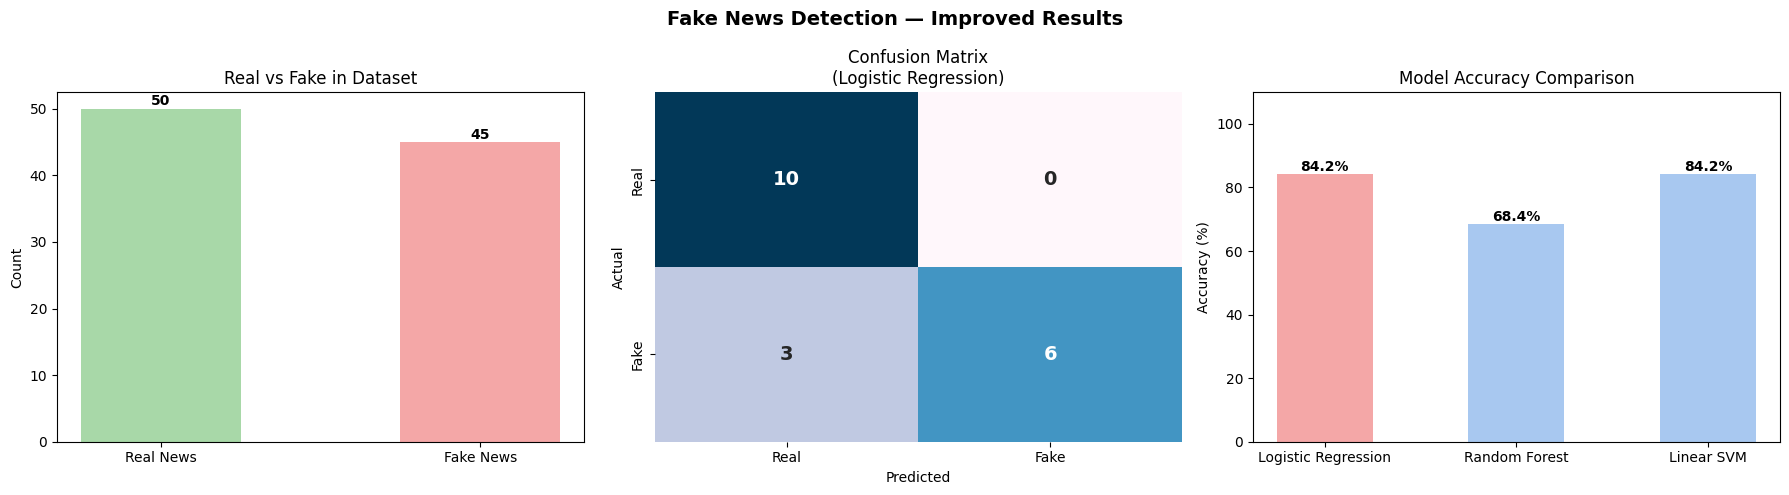


Charts saved!


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fake News Detection — Improved Results', fontsize=14, fontweight='bold')

# Chart 1: Class Distribution
axes[0].bar(['Real News', 'Fake News'],
            [(df['label']==0).sum(), (df['label']==1).sum()],
            color=['#a8d8a8', '#f4a7a7'], width=0.5)
axes[0].set_title('Real vs Fake in Dataset')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold')

# Chart 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'],
            ax=axes[1], cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title(f'Confusion Matrix\n({best_name})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Chart 3: Model Accuracy Comparison
model_names = list(results.keys())
accuracies  = [v * 100 for v in results.values()]
colors      = ['#f4a7a7' if n == best_name else '#a8c8f0' for n in model_names]
bars = axes[2].bar(model_names, accuracies, color=colors, width=0.5)
axes[2].set_title('Model Accuracy Comparison')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim([0, 110])
for bar, acc in zip(bars, accuracies):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{acc:.1f}%',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fake_news_charts_improved.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nCharts saved!')







